# BERT：Encoder-Only 预训练

> 我们已经知道，GPT 用 causal mask 保证每个 token 只能看到它前面的内容——从左到右，单向生成。但 Transformer 论文里还有另一半：Encoder，它不做 causal mask。
>
> 这一节，我们实现一个 Encoder-Only 模型 MiniBERT。去掉 causal mask 之后，每个 token 能同时看到整句话的所有位置，模型的能力从「生成下一个词」转向「理解整句话」。预训练任务也从自回归变成了 MLM——随机遮住一些 token，让模型根据上下文填空。

BERT 是一个只用 Transformer Encoder 的模型。它和 GPT 最本质的区别在 Attention 的方向上：GPT 用 causal mask 让每个 token 只能看到前面的内容（单向），BERT 不做 mask，让每个 token 同时看到整句话的所有位置（双向）。这种双向设计让 BERT 天然适合「理解」任务——先通读全文，再回答关于这篇文章的任何问题。BERT 的预训练任务叫 MLM（Masked Language Modeling）：随机遮住输入中 15% 的 token，模型根据前后文把被遮住的词填回来。这个任务迫使模型学会利用双向上下文信息，而不是简单地「从左到右猜下一个词」。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)

## 1. Encoder vs Decoder：先搞清楚架构上的本质区别

单向和双向的区别，用一句话就能说清楚。给定句子「我把苹果吃了」，causal mask 下模型看到「我把」时完全不知道后面是「苹果」还是「手机」——只能猜。双向 Attention 下，模型同时看到「我」「把」「苹果」「吃了」——每个词都能参考整句话的所有位置，所以它知道「苹果」是宾语而不是主语。

这个区别决定了模型适合做什么。GPT 适合生成——每次只能看到已经写出来的部分，写完一个词才能看下一个。BERT 适合理解——先通读全文，再回答关于这篇文章的任何问题。

在深入 BERT 之前，需要先明确 Encoder 和 Decoder 在 Attention 上的根本差异：

```
        Encoder-Only (BERT)          Decoder-Only (GPT)
        ────────────────             ────────────────

        输出: "B-PER"                   输出: "法"
          ↑                               ↑
    ┌─────┴─────┐                   ┌─────┴─────┐
    │  FFN + LN  │                   │  FFN + LN  │
    ├───────────┤                   ├───────────┤
    │ Attention │                   │ Attention │
    │ (双向! )  │                   │ (单向! )  │
    ├───────────┤                   ├───────────┤
    │  Input     │                   │  Input     │
    └───────────┘                   └───────────┘

   每个词能看到所有词              每个词只能看到前面的词
   （包括前面和后面）              （因果掩码）
```

同一个词「苹果」，在两种 Attention

## 2. BERT 的输入表示：Token + Segment + Position 三合一

BERT 的输入不是简单的一个 Embedding，而是**三个 Embedding 相加**：

```
输入 = Token Embedding + Segment Embedding + Position Embedding
         ↑                    ↑                    ↑
   "这个词本身是谁"    "属于句子A还是句子B"   "在哪个位置"
```

这和 GPT 的区别在哪？GPT 只有 Token + Position，不需要 Segment（因为 GPT 不处理"两个句子之间的关系"）。

**为什么 BERT 需要 Segment Embedding？** 因为 NSP（下一句预测）任务需要判断两个句子的关系。

下面用代码展示 BERT 的「完整输入构造过程」：

In [2]:
# ============================================================
# 手动构造 BERT 的输入（从零开始，一步步展示）
# ============================================================

# 模拟一个小 BERT 的配置
VOCAB_SIZE = 100
D_MODEL = 16
MAX_LEN = 20
NUM_SEGMENTS = 2  # 句子 A 或 句子 B

# 三个 Embedding
token_embed = nn.Embedding(VOCAB_SIZE, D_MODEL)
segment_embed = nn.Embedding(NUM_SEGMENTS, D_MODEL)
position_embed = nn.Embedding(MAX_LEN, D_MODEL)

# 模拟输入：两个句子
#   [CLS] 我 喜欢 猫 [SEP] 他 喜欢 狗 [SEP]
#   其中 [CLS]=1, [SEP]=2

sentence_A = [1, 5, 8, 3, 2]    # [CLS] 我 喜欢 猫 [SEP]
sentence_B = [6, 8, 4, 2]        # 他 喜欢 狗 [SEP]
full_ids = sentence_A + sentence_B
seq_len = len(full_ids)

print("Step 1: Token IDs")
print(f"  Input: {full_ids}")
print(f"  含义: [CLS] 我 喜欢 猫 [SEP] 他 喜欢 狗 [SEP]")

# Segment IDs：句子 A 的 token 标 0，句子 B 的 token 标 1
segment_ids = [0] * len(sentence_A) + [1] * len(sentence_B)
print(f"\nStep 2: Segment IDs")
print(f"  Segments: {segment_ids}")
print(f"  含义: 前 {len(sentence_A)} 个属于句子A(0)，后 {len(sentence_B)} 个属于句子B(1)")

# Position IDs：0, 1, 2, ..., seq_len-1
position_ids = list(range(seq_len))
print(f"\nStep 3: Position IDs")
print(f"  Positions: {position_ids}")

# ============================================================
# 三个 Embedding 相加
# ============================================================
tokens_t = torch.tensor(full_ids)
segments_t = torch.tensor(segment_ids)
positions_t = torch.tensor(position_ids)

tok_emb = token_embed(tokens_t)    # (seq_len, D_MODEL)
seg_emb = segment_embed(segments_t)  # (seq_len, D_MODEL)
pos_emb = position_embed(positions_t)  # (seq_len, D_MODEL)

input_embeddings = tok_emb + seg_emb + pos_emb

print(f"\nStep 4: 三个 Embedding 相加")
print(f"  Token Embedding shape:    {tok_emb.shape}")
print(f"  Segment Embedding shape:  {seg_emb.shape}")
print(f"  Position Embedding shape: {pos_emb.shape}")
print(f"  相加后: {input_embeddings.shape}")

# 展示：同一个词（"喜欢"，id=8）在两个句子中的 embedding 不同
# "喜欢" 在句子 A 的位置 2，在句子 B 的位置 1
idx_a = 2  # 句子 A 中的 "喜欢"
idx_b = len(sentence_A) + 1  # 句子 B 中的 "喜欢"

print(f"\n★ 关键证明：同一个词在不同位置 + 不同句子的 embedding 不同")
print(f"  '喜欢' 在句子A (pos={idx_a}, seg=0) 的最终 embedding (前 6 维):")
print(f"    {input_embeddings[idx_a, :6].detach()}")
print(f"  '喜欢' 在句子B (pos={idx_b}, seg=1) 的最终 embedding (前 6 维):")
print(f"    {input_embeddings[idx_b, :6].detach()}")
print(f"  它们一样吗？ {(input_embeddings[idx_a] == input_embeddings[idx_b]).all().item()}")
print(f"  → 即使词相同，但因为位置和 segment 不同，最终 embedding 也不同！")

Step 1: Token IDs
  Input: [1, 5, 8, 3, 2, 6, 8, 4, 2]
  含义: [CLS] 我 喜欢 猫 [SEP] 他 喜欢 狗 [SEP]

Step 2: Segment IDs
  Segments: [0, 0, 0, 0, 0, 1, 1, 1, 1]
  含义: 前 5 个属于句子A(0)，后 4 个属于句子B(1)

Step 3: Position IDs
  Positions: [0, 1, 2, 3, 4, 5, 6, 7, 8]

Step 4: 三个 Embedding 相加
  Token Embedding shape:    torch.Size([9, 16])
  Segment Embedding shape:  torch.Size([9, 16])
  Position Embedding shape: torch.Size([9, 16])
  相加后: torch.Size([9, 16])

★ 关键证明：同一个词在不同位置 + 不同句子的 embedding 不同
  '喜欢' 在句子A (pos=2, seg=0) 的最终 embedding (前 6 维):
    tensor([ 1.7462,  1.3668, -1.6681, -0.8311, -0.6420,  3.6566])
  '喜欢' 在句子B (pos=6, seg=1) 的最终 embedding (前 6 维):
    tensor([ 1.8207, -0.1974, -1.4914,  0.9783, -1.8119,  1.2722])
  它们一样吗？ False
  → 即使词相同，但因为位置和 segment 不同，最终 embedding 也不同！


## 3. BERT 的核心：MLM（遮词填空）预训练

GPT 的训练任务是「给定前面的词，预测下一个词」（自回归）。
BERT 的训练任务是「遮住中间的某些词，让模型猜它们是什么」（MLM）。

```
GPT 的训练:  我 → 爱 → 你 → 中国
            只能看 → 方向

BERT 的训练: 我 [MASK] 你 中国  →  猜 [MASK] 是 "爱"
            看左边   看右边
```

BERT 能同时看到左右两边——因为它的 attention 是**双向**的（没有因果掩码）。
这使它擅长「理解」，但无法生成——因为它训练时从来没学过「一个一个往外蹦词」。

In [3]:
# ============================================================
# 演示 BERT 的双向 Attention（对比 GPT 的因果 Attention）
# ============================================================
seq_len = 6

# GPT 的因果掩码：每个位置只能看自己和前面的
causal_mask = torch.tril(torch.ones(seq_len, seq_len))

# BERT 没有掩码：每个位置看所有位置（双向）
bert_mask = torch.ones(seq_len, seq_len)

tokens = ["[CLS]", "我", "爱", "你", "中", "[SEP]"]

print("=== GPT 的因果 Attention（单向）===")
print(f"Tokens: {tokens}")
print()
for i in range(seq_len):
    visible = [tokens[j] for j in range(seq_len) if causal_mask[i, j] == 1]
    print(f"  位置 {i} ('{tokens[i]}') 能看到: {visible}")

print(f"\n=== BERT 的 Attention（双向）===")
for i in range(seq_len):
    visible = [tokens[j] for j in range(seq_len) if bert_mask[i, j] == 1]
    print(f"  位置 {i} ('{tokens[i]}') 能看到: {visible}")

print(f"\n关键区别:")
print(f"  GPT:  '你' 看不到 '中国'（还没生成）")
print(f"  BERT: '你' 能看到 '中国'（整句已知，双向看）")
print(f"  → BERT 理解上下文的能力更强！但无法做生成。")

=== GPT 的因果 Attention（单向）===
Tokens: ['[CLS]', '我', '爱', '你', '中', '[SEP]']

  位置 0 ('[CLS]') 能看到: ['[CLS]']
  位置 1 ('我') 能看到: ['[CLS]', '我']
  位置 2 ('爱') 能看到: ['[CLS]', '我', '爱']
  位置 3 ('你') 能看到: ['[CLS]', '我', '爱', '你']
  位置 4 ('中') 能看到: ['[CLS]', '我', '爱', '你', '中']
  位置 5 ('[SEP]') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']

=== BERT 的 Attention（双向）===
  位置 0 ('[CLS]') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']
  位置 1 ('我') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']
  位置 2 ('爱') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']
  位置 3 ('你') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']
  位置 4 ('中') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']
  位置 5 ('[SEP]') 能看到: ['[CLS]', '我', '爱', '你', '中', '[SEP]']

关键区别:
  GPT:  '你' 看不到 '中国'（还没生成）
  BERT: '你' 能看到 '中国'（整句已知，双向看）
  → BERT 理解上下文的能力更强！但无法做生成。


## 4. 完整演示：MLM 是怎么训练的

MLM 的训练思路很直接，但和自回归语言模型的训练有本质区别：

- **自回归模型**（如 GPT）：输入 token[0:n]，预测 token[1:n+1]，每个位置都参与 loss 计算。这是「从左到右逐个预测」的模式。
- **MLM**：只随机遮住 15% 的 token，模型看到完整上下文（包括被遮位置右边的内容），但要预测的只有被遮住的那 15%。Loss 只在被遮住的位置上计算。

为什么 MLM 只算 15% 位置的 loss？因为未被遮住的 token 模型可以直接「看到」自己，如果不加 mask 直接预测，模型只需要学会 copy 输入就行了，什么也学不到。

下面构建一个 MiniBERT，展示完整的 MLM 训练流程：
1. 随机遮住 15% 的 token（其中 80% 替换为 [MASK]，10% 替换为随机 token，10% 保持不变）
2. 模型利用双向上下文预测被遮住的 token
3. Loss 只在被遮住的位置上计算

In [4]:
# ============================================================
# MiniBERT：只用 Encoder（双向 Attention，无因果掩码）
# ============================================================
class MiniBERTEncoder(nn.Module):
    """和 MiniGPT 类似的 Transformer Block，但没有因果掩码（双向）"""
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, S, D = x.shape
        Q = self.W_Q(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # ★ 没有 mask！双向！
        attn = F.softmax(scores, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, S, D)
        return self.W_O(out)

class MiniBERTBlock(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.attention = MiniBERTEncoder(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

class MiniBERT(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=2, max_len=64):
        super().__init__()
        self.d_model = d_model
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        # BERT 使用学习式位置编码（不是正弦）
        self.position_embedding = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList([
            MiniBERTBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.norm_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)
        self.max_len = max_len

    def encode(self, x):
        """返回每个位置的 hidden state，供分类/问答等任务复用"""
        B, S = x.shape
        positions = torch.arange(S, device=x.device).unsqueeze(0)
        x_emb = self.token_embedding(x) + self.position_embedding(positions)
        for block in self.blocks:
            x_emb = block(x_emb)
        x_emb = self.norm_final(x_emb)
        return x_emb

    def forward(self, x):
        x_emb = self.encode(x)
        return self.lm_head(x_emb)

print("MiniBERT 定义完毕（双向 Attention，无因果掩码）")

MiniBERT 定义完毕（双向 Attention，无因果掩码）


In [5]:
# ============================================================
# MLM 训练数据构造 + 训练演示
# ============================================================
VOCAB_SIZE = 50
MASK_ID = 3  # [MASK] 的 ID

torch.manual_seed(42)
model = MiniBERT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 模拟训练句子
sentences = [
    [5, 8, 10, 6, 9, 4],   # 我 喜欢 猫 它 很 可爱
    [5, 12, 13, 14, 4],    # 我 讨厌 下雨 天
    [7, 8, 11, 6, 15, 4],  # 他 喜欢 狗 它 忠诚
    [5, 16, 17, 18, 4],    # 我 在 学习 编程
    [7, 16, 19, 20, 4],    # 他 在 听 音乐
    [5, 21, 22, 9, 23, 4], # 我 觉得 数学 很 难
]

# MLM 数据构造函数
def create_mlm_batch(sentences, mask_prob=0.15):
    """
    和真实 BERT 一样：
    - 15% 的 token 被选中
    - 其中 80% 替换为 [MASK]
    - 10% 替换为随机 token
    - 10% 保持不变（但还是要预测）
    """
    # Padding
    max_len = max(len(s) for s in sentences)
    batch_size = len(sentences)
    input_ids = torch.zeros(batch_size, max_len, dtype=torch.long)
    labels = torch.full((batch_size, max_len), -100, dtype=torch.long)  # -100 = ignore

    for i, sent in enumerate(sentences):
        input_ids[i, :len(sent)] = torch.tensor(sent)

        # 选择要 mask 的位置（15%），但不 mask 第一个和最后一个
        maskable = list(range(1, len(sent) - 1))
        num_mask = max(1, int(len(maskable) * mask_prob))
        mask_positions = torch.randperm(len(maskable))[:num_mask]

        for pos_idx in mask_positions:
            pos = maskable[pos_idx]
            labels[i, pos] = sent[pos]  # 记录原始 token
            rand = torch.rand(1).item()
            if rand < 0.8:
                input_ids[i, pos] = MASK_ID  # 80%: 替换为 [MASK]
            elif rand < 0.9:
                input_ids[i, pos] = torch.randint(5, 25, (1,)).item()  # 10%: 随机
            # 10%: 保持不变

    return input_ids, labels

# 创建 batch
input_ids, labels = create_mlm_batch(sentences)

print("=== MLM 训练数据示例 ===")
print(f"MASK_ID = {MASK_ID}")
print()
for i in range(len(sentences)):
    print(f"句子 {i+1}:")
    print(f"  原始: {sentences[i]}")
    print(f"  输入: {input_ids[i].tolist()}")
    label_row = labels[i].tolist()
    print(f"  labels: {[('MASK→'+str(l) if l != -100 else 'ignore') for l in label_row]}")
    print()

# ============================================================
# 训练
# ============================================================
print("=== 训练 MiniBERT (MLM) ===")
NUM_EPOCHS = 200
losses = []

model.train()
for epoch in range(NUM_EPOCHS):
    optimizer.zero_grad()
    logits = model(input_ids)  # (B, S, V)
    loss = F.cross_entropy(
        logits.view(-1, VOCAB_SIZE),
        labels.view(-1),
        ignore_index=-100  # 忽略非 mask 位置
    )
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 20 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print(f"\n初始 Loss: {losses[0]:.4f} → 最终 Loss: {losses[-1]:.4f}")

=== MLM 训练数据示例 ===
MASK_ID = 3

句子 1:
  原始: [5, 8, 10, 6, 9, 4]
  输入: [5, 8, 3, 6, 9, 4]
  labels: ['ignore', 'ignore', 'MASK→10', 'ignore', 'ignore', 'ignore']

句子 2:
  原始: [5, 12, 13, 14, 4]
  输入: [5, 3, 13, 14, 4, 0]
  labels: ['ignore', 'MASK→12', 'ignore', 'ignore', 'ignore', 'ignore']

句子 3:
  原始: [7, 8, 11, 6, 15, 4]
  输入: [7, 8, 11, 3, 15, 4]
  labels: ['ignore', 'ignore', 'ignore', 'MASK→6', 'ignore', 'ignore']

句子 4:
  原始: [5, 16, 17, 18, 4]
  输入: [5, 16, 17, 3, 4, 0]
  labels: ['ignore', 'ignore', 'ignore', 'MASK→18', 'ignore', 'ignore']

句子 5:
  原始: [7, 16, 19, 20, 4]
  输入: [7, 16, 19, 3, 4, 0]
  labels: ['ignore', 'ignore', 'ignore', 'MASK→20', 'ignore', 'ignore']

句子 6:
  原始: [5, 21, 22, 9, 23, 4]
  输入: [5, 21, 3, 9, 23, 4]
  labels: ['ignore', 'ignore', 'MASK→22', 'ignore', 'ignore', 'ignore']

=== 训练 MiniBERT (MLM) ===
Epoch   0 | Loss: 3.8524
Epoch  20 | Loss: 0.5691
Epoch  40 | Loss: 0.1018
Epoch  60 | Loss: 0.0474
Epoch  80 | Loss: 0.0309
Epoch 100 | Loss: 0.0227


Epoch 120 | Loss: 0.0177
Epoch 140 | Loss: 0.0142
Epoch 160 | Loss: 0.0116
Epoch 180 | Loss: 0.0097
Epoch 199 | Loss: 0.0083

初始 Loss: 3.8524 → 最终 Loss: 0.0083


=== MLM 预测结果 ===
输入:  [5, 3, 10, 6, 3, 4]
       ['我', '[MASK]', '猫', '它', '[MASK]', '可爱']
预测:  [12, 12, 10, 18, 12, 22]
       ['我', '?', '猫', '它', '?', '可爱']

位置 1 (预测) = 12 (期望 8='喜欢')
位置 4 (预测) = 12 (期望 9='很')


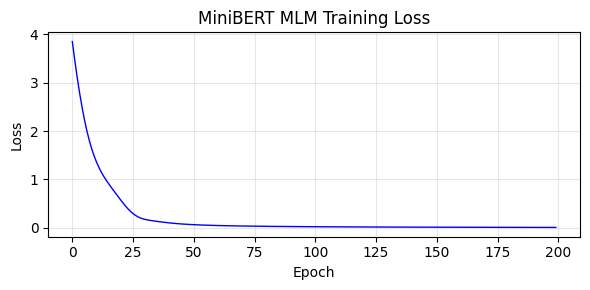

In [6]:
# ============================================================
# 测试：MLM 预测效果
# ============================================================
test_sentence = torch.tensor([[5, MASK_ID, 10, 6, MASK_ID, 4]])  # 我 [MASK] 猫 它 [MASK] 可爱

model.eval()
with torch.no_grad():
    logits = model(test_sentence)
    predictions = logits.argmax(dim=-1)

print("=== MLM 预测结果 ===")
print(f"输入:  {test_sentence.tolist()[0]}")
print(f"       ['我', '[MASK]', '猫', '它', '[MASK]', '可爱']")
print(f"预测:  {predictions.tolist()[0]}")
print(f"       ['我', '?', '猫', '它', '?', '可爱']")
print(f"\n位置 1 (预测) = {predictions[0, 1].item()} (期望 8='喜欢')")
print(f"位置 4 (预测) = {predictions[0, 4].item()} (期望 9='很')")

# Visualize loss
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(losses, 'b-', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MiniBERT MLM Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. BERT 的微调范式：不同下游任务怎么接？

BERT 预训练完后，不同下游任务只需在顶层接不同的分类头。关键问题是：**分类头接在哪里？**

预训练好的 BERT 本体是一个「通用文本编码器」——输入一段文本，输出每个 token 的 hidden state。不同任务需要的信息位置不同：

| 任务 | 需要什么信息 | 分类头接在哪里 |
|------|------------|-------------|
| **单句分类**（情感分析） | 整句话的语义 | `[CLS]` 的 hidden → 分类层 |
| **句对分类**（NLI、相似度） | 两句的关系 | `[CLS]` 的 hidden → 分类层 |
| **序列标注**（NER） | 每个词的类别 | **每个 token** 的 hidden → 各自的分类层 |
| **问答**（SQuAD） | 答案的起止位置 | 每个 token 的 hidden → start/end 两个分类层 |

为什么单句和句对分类都取 `[CLS]`？因为 `[CLS]` 在 BERT 的输入最前面，经过多层双向 Attention 后，整句话的信息被聚合到了 `[CLS]` 的 hidden state 里——它是一个「整句摘要」。直接拿它过一个分类层就能做句子级别的判断。

序列标注任务（比如 NER：给「苹果发布新手机」标注为 `[ORG, O, O, O]`）需要每个 token 各自的类别，所以不能只取 `[CLS]`——需要对每个位置的 hidden state 分别做分类。

核心洞察：**BERT 本体通常不动（或只做微小的微调），只换最后的「头」。**这和 GPT 的 prompt engineering 是不同的使用范式——BERT 靠换头适配任务，GPT 靠换 prompt 适配任务。</cell>


In [7]:
# ============================================================
# 演示：用 MiniBERT 做句子分类
# ============================================================
class MiniBERTForClassification(nn.Module):
    """在 MiniBERT 上接一个分类头"""
    def __init__(self, bert, num_classes):
        super().__init__()
        self.bert = bert
        self.classifier = nn.Linear(bert.d_model, num_classes)

    def forward(self, x):
        hidden = self.bert.encode(x)  # (B, S, D)
        cls_output = hidden[:, 0, :]  # 取 [CLS] 的输出
        return self.classifier(cls_output)  # → (B, num_classes)

# 演示
VOCAB_SIZE = 50
bert_base = MiniBERT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)
clf_model = MiniBERTForClassification(bert_base, num_classes=2)  # 二分类：正面/负面

test_input = torch.randint(0, VOCAB_SIZE, (1, 10))
output = clf_model(test_input)
print(f"输入 shape: {test_input.shape}")
print(f"输出 shape: {output.shape}  ← (batch=1, classes=2)")
print(f"输出 logits: {output.tolist()}")
print(f"\n这就是 BERT 做情感分析的完整流程：")
print(f"  输入句子 → BERT 编码 → 取 [CLS] → 分类层 → 正面/负面")

输入 shape: torch.Size([1, 10])
输出 shape: torch.Size([1, 2])  ← (batch=1, classes=2)
输出 logits: [[-0.058426402509212494, 0.5479098558425903]]

这就是 BERT 做情感分析的完整流程：
  输入句子 → BERT 编码 → 取 [CLS] → 分类层 → 正面/负面


## 6. 真实 BERT 加载演示（transformers 库）

上面我们从零实现了 MiniBERT，理解了 Encoder-only 架构和 MLM 训练的底层机制。现在用 HuggingFace transformers 加载一个真正的 BERT 模型，看看工业级实现和我们自己实现的版本的结构对应关系。

需要关注的是：真正的 BERT 在三个维度上做了扩展——
- **规模**：BERT-base 有 12 层 Transformer block、768 维 hidden size、12 个 attention head，总参数量约 110M
- **词表**：用了 30,522 个 token 的 WordPiece 词表，远比我们演示用的几十个 token 大
- **预训练数据**：BooksCorpus（800M 词）+ 英文 Wikipedia（2,500M 词）

但核心结构和我们实现的 MiniBERT 一致：都是 Encoder-only、都用双向 attention、都通过 MLM 预训练来学习上下文理解能力。

In [8]:
# ============================================================
# 用 transformers 加载真实 BERT
# ============================================================
try:
    from transformers import AutoTokenizer, AutoModel

    print("加载 BERT-base-chinese...")
    tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
    model = AutoModel.from_pretrained("bert-base-chinese")

    print(f"BERT 参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")
    print(f"词表大小: {len(tokenizer)}")
    print()

    # 测试：看 BERT 的 attention 权重
    sentences = [
        "我爱中国",
        "今天天气真好",
    ]

    inputs = tokenizer(sentences, padding=True, return_tensors="pt")
    print(f"输入 IDs shape: {inputs['input_ids'].shape}")
    print(f"Attention mask: {inputs['attention_mask']}")
    print()

    # 前向传播
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    print(f"输出 last_hidden_state shape: {outputs.last_hidden_state.shape}")
    print(f"  → (batch, seq_len, hidden_dim=768)")
    print()

    # 看最后一层的 attention（第一个 head）
    last_layer_attn = outputs.attentions[-1]  # (batch, num_heads, seq_len, seq_len)
    print(f"最后一层 attention shape: {last_layer_attn.shape}")
    print(f"  → (batch, 12 heads, seq_len, seq_len)")
    print()

    # 展示第一个句子每个 token 能看到谁
    tokens1 = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    print(f"句子 1 tokens: {tokens1}")
    print(f"\n每个 token 的 attention 分布（head 0）:")
    for i, tok in enumerate(tokens1):
        attn_weights = last_layer_attn[0, 0, i]  # 第 0 个样本，第 0 个 head，第 i 个 position
        top2 = attn_weights.topk(2)
        print(f"  '{tok}' 最关注: ", end="")
        for j, (idx, w) in enumerate(zip(top2.indices, top2.values)):
            print(f"'{tokens1[idx]}'({w:.2f})", end="  ")
        print()

except ImportError:
    print("transformers 库未安装。运行: pip install transformers")
except Exception as e:
    print(f"加载 BERT 时出错: {e}")
    print("(这是正常的——如果网络不通或模型太大，以上面的 MiniBERT 演示为准)")

transformers 库未安装。运行: pip install transformers


## 7. BERT vs GPT：一张表说清本质区别

| | BERT (Encoder-Only) | GPT (Decoder-Only) |
|------|------|------|
| **核心任务** | 理解——「这句话什么意思？」 | 生成——「下一句该说什么？」 |
| **预训练** | MLM（遮词填空，15% mask） | 自回归（预测下一个词） |
| **Attention** | 双向（看整句） | 单向/因果（只看前面） |
| **输入表示** | Token + Segment + Position | Token + Position（无 Segment） |
| **输出** | 每个位置的 hidden state | 每个位置的 logits（但生成时只用最后一个） |
| **怎么用** | 加分类头微调 | 改 prompt / 对话格式 |
| **代表模型** | BERT, RoBERTa, DeBERTa | GPT-3/4, LLaMA, Qwen, DeepSeek |
| **为什么 GPT 赢了** | BERT 做不了生成，且规模扩展后涌现能力不如 GPT | GPT 通过 in-context learning 也能做理解任务 |

BERT 和 GPT 是同一篇 Transformer 论文的两种用法——一个用 Encoder 做理解，一个用 Decoder 做生成。GPT 在规模竞赛中胜出了，但 BERT 的思想没有消失：

- RoBERTa 去掉了 BERT 的 NSP 任务（发现它没用），只用 MLM，更多数据训更久，效果显著提升
- DistilBERT 通过知识蒸馏把 BERT 缩小 40%，速度提高 60%，但保持了 97% 的效果
- DeBERTa 改进了 Attention 机制（解耦相对位置和内容），一度在 SuperGLUE 上超越人类基准
- MLM 的「遮住一部分让模型猜」策略被 T5、BART 甚至现代多模态模型广泛吸收

**一句话总结**：BERT 用双向 Attention 做 MLM，擅长理解但不擅长生成。GPT 用单向 Attention 做自回归，擅长生成且随着规模增长涌现了理解能力。BERT 的 MLM 思想和双向编码设计至今仍影响着整个 NLP 领域。</cell>
